# UMC: Taiwan ordinary (2303.TW) vs US ADR (UMC)

Question: after normalizing the ADR by its conversion ratio and FX, do the two
trade as the same asset?

**Facts used:**
- Taiwan ordinary share: `2303.TW`, priced in TWD.
- US ADR: `UMC` (NYSE), priced in USD.
- ADR ratio: **1 ADR = 5 ordinary shares**.
- FX: `TWD=X` = USD/TWD (TWD per 1 USD).

So the ADR's implied price per ordinary share, in TWD, is:

    adr_implied_twd = UMC_usd / 5 * (TWD per USD)

If they are the same asset (no arb, ignoring frictions), `adr_implied_twd ≈ 2303.TW close`.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ADR_RATIO = 5  # 1 ADR = 5 ordinary shares

tickers = ["2303.TW", "UMC", "TWD=X"]
raw = yf.download(tickers, period="10y", auto_adjust=False)["Close"]
raw = raw.rename(columns={"2303.TW": "tw_twd", "UMC": "adr_usd", "TWD=X": "usdtwd"})
raw.tail()

[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

Ticker,tw_twd,usdtwd,adr_usd
Date,,,
2026-06-29,164.0,31.847000,26.840000
2026-06-30,164.5,31.865900,27.209999
2026-07-01,169.0,31.834400,25.709999
2026-07-02,165.5,31.894800,24.540001
2026-07-03,170.5,31.922001,NaN


In [2]:
# Align on common trading days, forward-fill FX gaps, drop rows missing any leg.
df = raw.copy()
df["usdtwd"] = df["usdtwd"].ffill()
df = df.dropna(subset=["tw_twd", "adr_usd", "usdtwd"])

# ADR implied price per ordinary share, in TWD.
df["adr_implied_twd"] = df["adr_usd"] / ADR_RATIO * df["usdtwd"]

# Premium/discount of ADR vs local (%).
df["premium_pct"] = (df["adr_implied_twd"] / df["tw_twd"] - 1) * 100
df[["tw_twd", "adr_implied_twd", "premium_pct"]].tail()

Ticker,tw_twd,adr_implied_twd,premium_pct
Date,,,
2026-06-26,164.0,162.995763,-0.612340
2026-06-29,164.0,170.954698,4.240669
2026-06-30,164.5,173.414222,5.418980
2026-07-01,169.0,163.692480,-3.140544
2026-07-02,165.5,156.539685,-5.414088


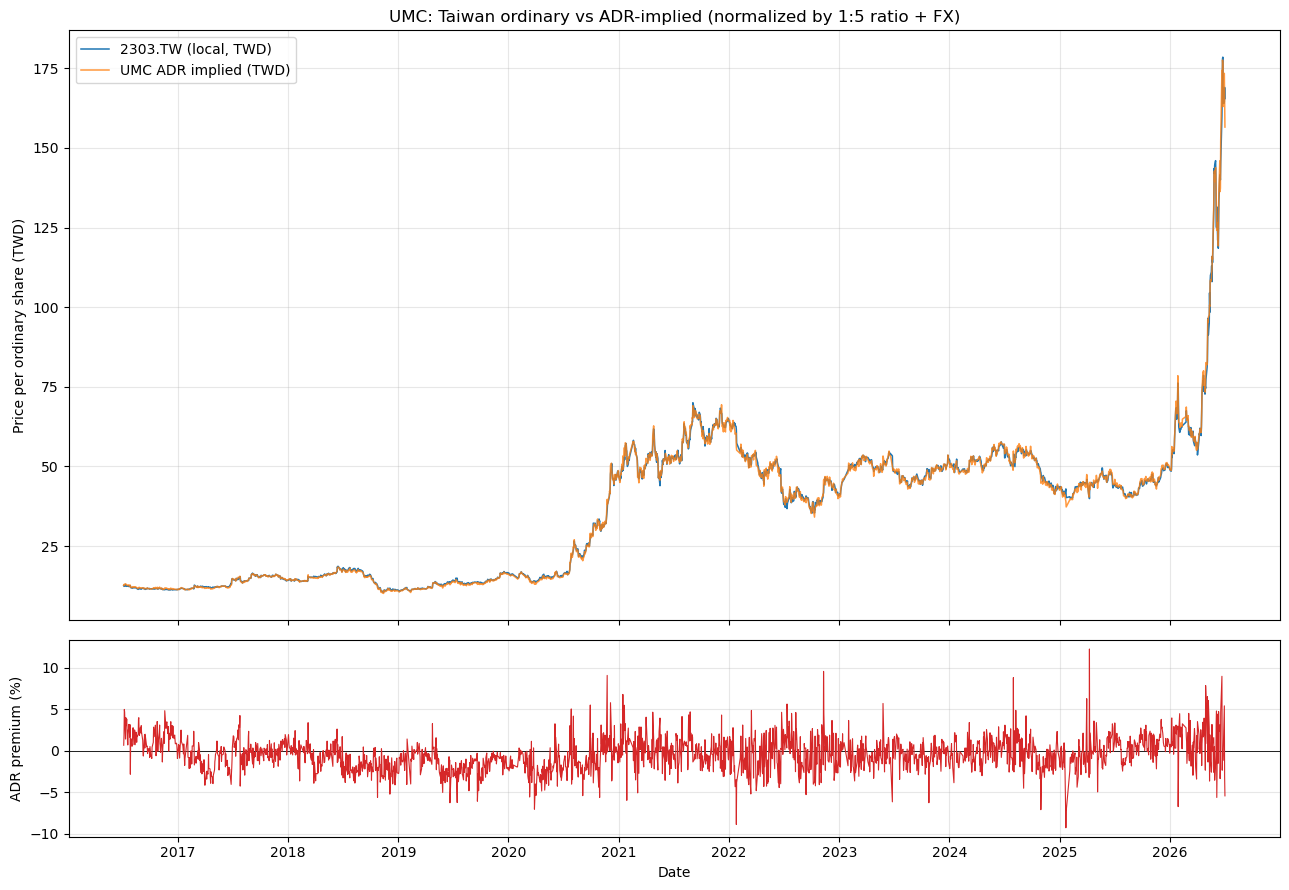

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})

ax[0].plot(df.index, df["tw_twd"], label="2303.TW (local, TWD)", lw=1.1)
ax[0].plot(df.index, df["adr_implied_twd"], label="UMC ADR implied (TWD)",
           lw=1.1, alpha=0.8)
ax[0].set_ylabel("Price per ordinary share (TWD)")
ax[0].set_title("UMC: Taiwan ordinary vs ADR-implied (normalized by 1:5 ratio + FX)")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].axhline(0, color="k", lw=0.6)
ax[1].plot(df.index, df["premium_pct"], color="C3", lw=0.8)
ax[1].set_ylabel("ADR premium (%)")
ax[1].set_xlabel("Date")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# How tightly do they track? Correlation of daily returns + premium stats.
ret = df[["tw_twd", "adr_implied_twd"]].pct_change().dropna()
corr = ret["tw_twd"].corr(ret["adr_implied_twd"])

print(f"Daily-return correlation: {corr:.4f}")
print(f"ADR premium (%)  mean {df['premium_pct'].mean():+.2f}  "
      f"std {df['premium_pct'].std():.2f}  "
      f"min {df['premium_pct'].min():+.2f}  max {df['premium_pct'].max():+.2f}")
print("\nInterpretation: high return-correlation + a small, mean-reverting")
print("premium band => effectively the same asset (premium = arb/FX/timing friction).")
print("Note: TW and US sessions don't overlap, so daily 'premium' partly reflects")
print("non-synchronous closes, not just true mispricing.")

Daily-return correlation: 0.6333
ADR premium (%)  mean -0.41  std 1.98  min -9.26  max +12.26

Interpretation: high return-correlation + a small, mean-reverting
premium band => effectively the same asset (premium = arb/FX/timing friction).
Note: TW and US sessions don't overlap, so daily 'premium' partly reflects
non-synchronous closes, not just true mispricing.
